# TopCoW 2024 to NPZ Conversion and Visualization

This notebook converts the TopCoW 2024 challenge datasets into a unified `.npz` format for training. It supports both:
- **CT**: CTA scans.
- **MR**: MRA scans.

In [ ]:
import sys
from pathlib import Path
import os
import numpy as np

parent = Path().resolve().parent.parent 
sys.path.append(str(parent))

from data.train_data.top_cow_to_npz import process_topcow
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp

## 1. Process TopCoW CT Dataset

Processing the TopCoW CTA dataset. Data is cropped and resampled to 1.0mm isotropic.

In [2]:
data_dir = "TopCoW_2024"
output_ct = "TopCoW_CT"

if os.path.exists(data_dir):
    process_topcow(
        data_dir=data_dir, 
        output_path=output_ct,
        modality="ct",
        resample=True,
        crop=True,
        margin=15,
        max_patients=18
    )
else:
    print(f"Directory {data_dir} not found.")


[1/18] Processing topcow_ct_002 ...
  Native spacing: ('0.700', '0.457', '0.457') mm | shape: (203, 347, 289)
  Cropping to anatomy (margin=15) ...
  -> Cropped shape: (65, 347, 289)
  Resampling from ('0.700', '0.457', '0.457') mm -> 1.0 mm isotropic ...
  -> Resampled shape: (45, 159, 132)
  -> Success: topcow_ct_002

[2/18] Processing topcow_ct_011 ...
  Native spacing: ('0.500', '0.498', '0.498') mm | shape: (295, 334, 269)
  Cropping to anatomy (margin=15) ...
  -> Cropped shape: (99, 334, 269)
  Resampling from ('0.500', '0.498', '0.498') mm -> 1.0 mm isotropic ...
  -> Resampled shape: (50, 166, 134)
  -> Success: topcow_ct_011

[3/18] Processing topcow_ct_013 ...
  Native spacing: ('0.700', '0.402', '0.402') mm | shape: (168, 433, 326)
  Cropping to anatomy (margin=15) ...
  -> Cropped shape: (76, 433, 326)
  Resampling from ('0.700', '0.402', '0.402') mm -> 1.0 mm isotropic ...
  -> Resampled shape: (53, 174, 131)
  -> Success: topcow_ct_013

[4/18] Processing topcow_ct_017 .

## 2. Process TopCoW MR Dataset

Processing the TopCoW MRA dataset. Data is cropped and resampled to 1.0mm isotropic.

In [3]:
output_mr = "TopCoW_MR"

if os.path.exists(data_dir):
    process_topcow(
        data_dir=data_dir, 
        output_path=output_mr, 
        modality="mr",
        resample=True,
        crop=True,
        margin=15,
        max_patients=18
    )
else:
    print(f"Directory {data_dir} not found.")


[1/18] Processing topcow_mr_005 ...
  Native spacing: ('0.600', '0.297', '0.297') mm | shape: (196, 566, 470)
  Cropping to anatomy (margin=15) ...
  -> Cropped shape: (75, 566, 470)
  Resampling from ('0.600', '0.297', '0.297') mm -> 1.0 mm isotropic ...
  -> Resampled shape: (45, 168, 140)
  -> Success: topcow_mr_005

[2/18] Processing topcow_mr_011 ...
  Native spacing: ('0.600', '0.297', '0.297') mm | shape: (153, 581, 470)
  Cropping to anatomy (margin=15) ...
  -> Cropped shape: (88, 581, 470)
  Resampling from ('0.600', '0.297', '0.297') mm -> 1.0 mm isotropic ...
  -> Resampled shape: (53, 172, 140)
  -> Success: topcow_mr_011

[3/18] Processing topcow_mr_031 ...
  Native spacing: ('0.600', '0.297', '0.297') mm | shape: (208, 561, 473)
  Cropping to anatomy (margin=15) ...
  -> Cropped shape: (89, 561, 473)
  Resampling from ('0.600', '0.297', '0.297') mm -> 1.0 mm isotropic ...
  -> Resampled shape: (53, 167, 140)
  -> Success: topcow_mr_031

[4/18] Processing topcow_mr_035 .

## 3. Load and Visualize Results

Now we load the generated `.npz` file and visualize a few samples.

In [ ]:
# The actual file is right here in our current folder
local_file = "TopCoW_CT.npz"

# But DataLoader_npz needs the path relative to the project root
dataloader_path = "data/train_data/TopCoW_CT.npz"

if os.path.exists(local_file):
    dg = DataGenerator(DataLoader_npz([dataloader_path], val_size=0.0))
    all_ids = dg.dataloader.train_ids
    print(f"Loaded IDs: {all_ids}")
    
    if len(all_ids) > 0:
        sample_id = all_ids[0]
        img = dg.dataloader.dataset[sample_id]['image']
        mask = dg.dataloader.dataset[sample_id]['segmentations'][0]
        
        print(f"Sample: {sample_id}")
        print(f"Image shape: {img.shape}")
        print(f"Mask shape: {mask.shape}")
else:
    print(f"{local_file} not found locally.")

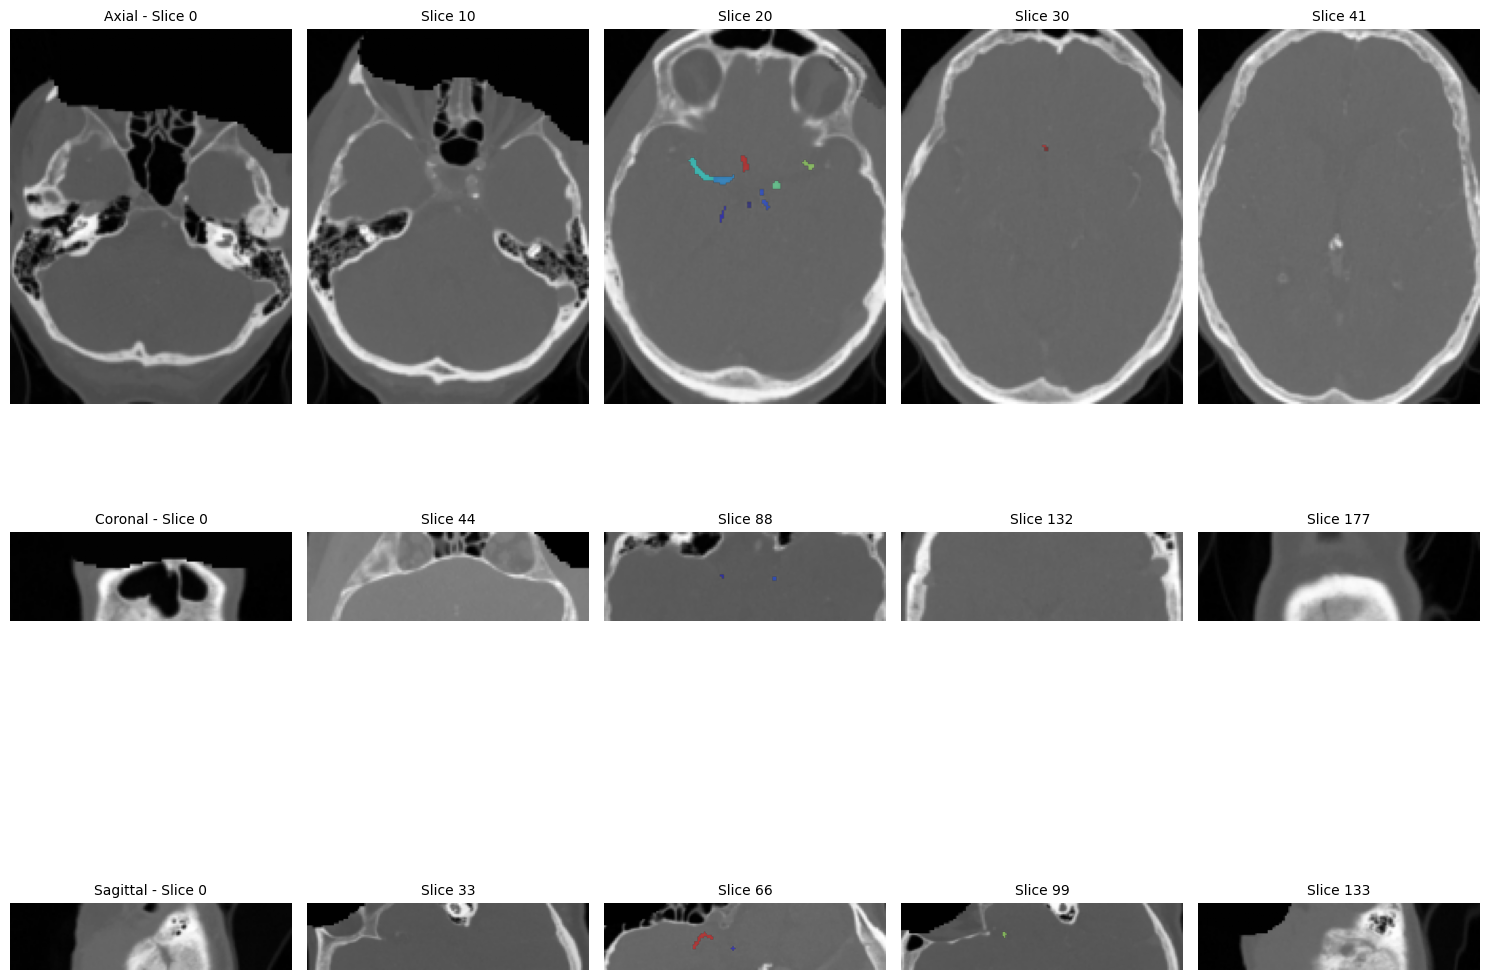

In [9]:
plot_vol_slices(img, mask)

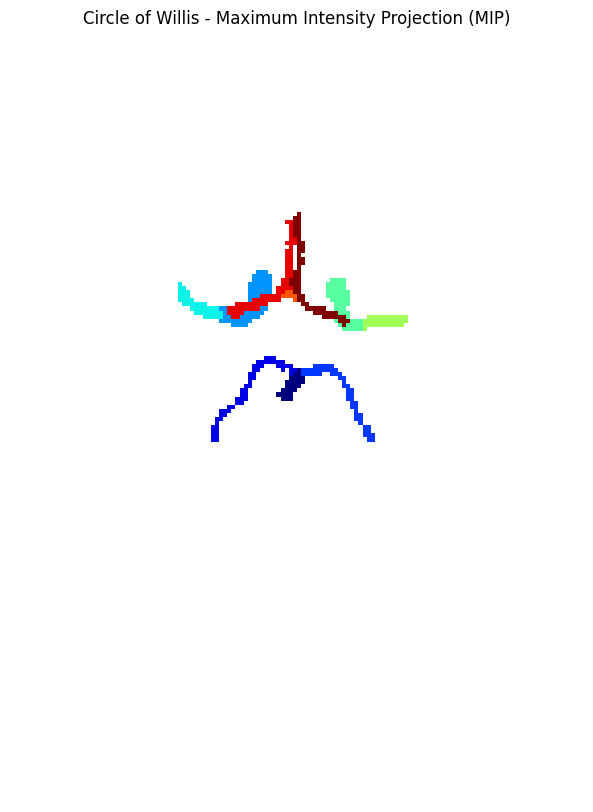

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Squash the 3D mask along the Z-axis (Axial projection)
# We use max() so any pixel that has a vessel in ANY slice shows up
mip_mask = np.max(mask, axis=0) 

plt.figure(figsize=(10, 10))
# We mask out the 0s so the background is transparent
m = np.ma.masked_where(mip_mask == 0, mip_mask)
plt.imshow(m, cmap='jet')
plt.title("Circle of Willis - Maximum Intensity Projection (MIP)")
plt.axis('off')
plt.show()